<a href="https://colab.research.google.com/github/1br4him858/Data-Analysis-projectt-/blob/main/WHO_Health_PySpark_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analysis & Machine Learning Project on Top causes of death dataset from WHO

##  Install and Import PySpark

In [76]:
!pip install pyspark

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, avg

import pandas

##  Create Spark Session

In [35]:
spark = SparkSession.builder \
    .appName('WHO Health Analysis') \
    .getOrCreate()

print('Spark Session Created Successfully')

Spark Session Created Successfully


##  Upload Dataset

In [62]:
from google.colab import files

uploaded = files.upload()

Saving GHE_FULL_DD.csv to GHE_FULL_DD (2).csv


##   Load Dataset

In [37]:
df = spark.read.csv(
    'GHE_FULL_DD.csv',
    header=True,
    inferSchema=True
)

df.show(5)

+----------------+-------------+--------------------+------------+-------------------------+
|DIM_COUNTRY_CODE|DIM_YEAR_CODE|  DIM_GHECAUSE_TITLE|DIM_SEX_CODE|VAL_DTHS_RATE100K_NUMERIC|
+----------------+-------------+--------------------+------------+-------------------------+
|             AFG|         2021|            Syphilis|        BTSX|                     1.46|
|             AFG|         2021|      Genital herpes|        BTSX|                      0.0|
|             AFG|         2021|          Diphtheria|        BTSX|                     0.11|
|             AFG|         2021|African trypanoso...|        BTSX|                      0.0|
|             AFG|         2021|              Dengue|        BTSX|                      0.0|
+----------------+-------------+--------------------+------------+-------------------------+
only showing top 5 rows


##  Explore Dataset

In [38]:
print('Number of Rows:', df.count())

print(df.columns)

df.printSchema()

Number of Rows: 24522
['DIM_COUNTRY_CODE', 'DIM_YEAR_CODE', 'DIM_GHECAUSE_TITLE', 'DIM_SEX_CODE', 'VAL_DTHS_RATE100K_NUMERIC']
root
 |-- DIM_COUNTRY_CODE: string (nullable = true)
 |-- DIM_YEAR_CODE: integer (nullable = true)
 |-- DIM_GHECAUSE_TITLE: string (nullable = true)
 |-- DIM_SEX_CODE: string (nullable = true)
 |-- VAL_DTHS_RATE100K_NUMERIC: double (nullable = true)



##   Select Important Columns

In [83]:
# Display Dataset in Table Format

display(df.limit(5).toPandas())

,country,year,cause,sex,deaths
0,AFG,2021,African trypanosomiasis,BTSX,0.00
1,AGO,2021,Food-bourne trematodes,BTSX,0.00
2,ARE,2021,Autism and Asperger syndrome,BTSX,0.00
3,ARE,2021,Testicular cancer,BTSX,0.03
4,ARG,2021,Acute hepatitis E,BTSX,0.01


##   Data Cleaning

In [40]:
df = df.dropna()

df = df.dropDuplicates()

print('Rows After Cleaning:', df.count())

Rows After Cleaning: 24522


## Filtering Operations

In [81]:
# Filter Egypt Data

egypt_df = df.filter(df.country == 'EGY')

# Display Egypt Data as Table

display(egypt_df.limit(10).toPandas())


# Filter Male Data

male_df = df.filter(df.sex == 'MLE')

# Display Male Data as Table

display(male_df.limit(10).toPandas())

,country,year,cause,sex,deaths
0,EGY,2021,Encephalitis,BTSX,0.63
1,EGY,2021,Epilepsy,BTSX,0.46
2,EGY,2021,Protein-energy malnutrition,BTSX,0.20
3,EGY,2021,COVID-19,BTSX,128.81
4,EGY,2021,Leprosy,BTSX,0.00
5,EGY,2021,Oesophagus cancer,BTSX,1.35
6,EGY,2021,Preterm birth complications,BTSX,10.47
7,EGY,2021,Cervix uteri cancer,BTSX,0.70
8,EGY,2021,Dengue,BTSX,0.00
9,EGY,2021,Chronic obstructive pulmonary disease,BTSX,8.80


,country,year,cause,sex,deaths


##  Grouping & Aggregation

In [82]:
from pyspark.sql.functions import format_number

# ==============================
# Top Causes of Death
# ==============================

cause_deaths = df.groupBy('cause') \
    .agg(sum('deaths').alias('total_deaths')) \
    .orderBy('total_deaths', ascending=False)

cause_deaths = cause_deaths.withColumn(
    'total_deaths',
    format_number('total_deaths', 2)
)

print("========== Top Causes of Death ==========")

display(cause_deaths.limit(10).toPandas())


# ==============================
# Average Deaths by Sex
# ==============================

avg_deaths_sex = df.groupBy('sex') \
    .agg(avg('deaths').alias('average_deaths'))

avg_deaths_sex = avg_deaths_sex.withColumn(
    'average_deaths',
    format_number('average_deaths', 2)
)

print("========== Average Deaths by Sex ==========")

display(avg_deaths_sex.toPandas())


# ==============================
# Yearly Deaths
# ==============================

yearly_deaths = df.groupBy('year') \
    .agg(sum('deaths').alias('total_deaths')) \
    .orderBy('year')

yearly_deaths = yearly_deaths.withColumn(
    'total_deaths',
    format_number('total_deaths', 2)
)

print("========== Yearly Deaths ==========")

display(yearly_deaths.toPandas())

========== Top Causes of Death ==========


,cause,total_deaths
0,Ischaemic heart disease,"21,302.02"
1,COVID-19,"20,294.23"
2,Stroke,"14,069.39"
3,Lower respiratory infections,"6,729.54"
4,Diabetes mellitus,"5,055.78"
5,Chronic obstructive pulmonary disease,"4,075.28"
6,Hypertensive heart disease,"3,979.18"
7,Kidney diseases,"3,817.97"
8,Alzheimer disease and other dementias,"3,711.33"
9,Tuberculosis,"3,515.97"


========== Average Deaths by Sex ==========


,sex,average_deaths
0,BTSX,5.82


========== Yearly Deaths ==========


,year,total_deaths
0,2021,"142,724.30"


# visualization

<Figure size 1200x600 with 0 Axes>

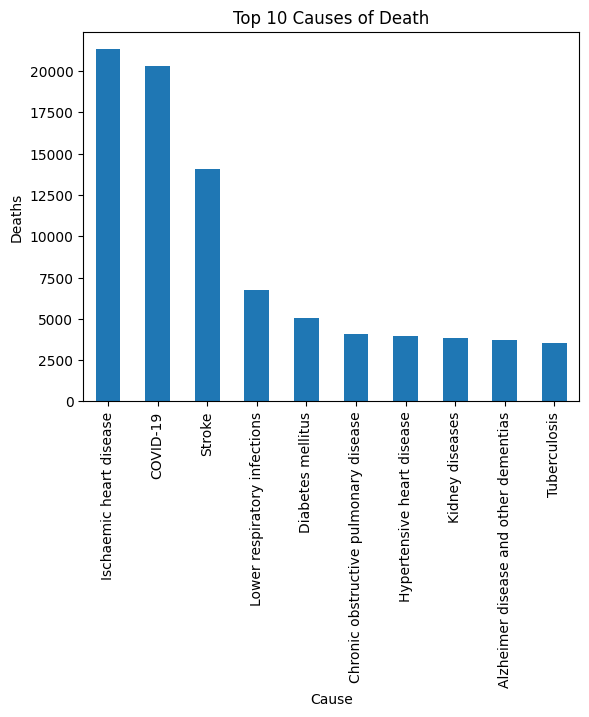

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
cause_deaths.limit(10).toPandas().plot(kind='bar', x='cause', y='total_deaths', legend=False)
plt.title('Top 10 Causes of Death')
plt.xlabel('Cause')
plt.ylabel('Deaths')
plt.show()

##   Insights

In [84]:
print("========== Top Causes of Death ==========")

display(cause_deaths.limit(5).toPandas())


print("========== Average Deaths by Sex ==========")

display(avg_deaths_sex.toPandas())


print("========== Deaths by Year ==========")

display(yearly_deaths.toPandas())

========== Top Causes of Death ==========


,cause,total_deaths
0,Ischaemic heart disease,"21,302.02"
1,COVID-19,"20,294.23"
2,Stroke,"14,069.39"
3,Lower respiratory infections,"6,729.54"
4,Diabetes mellitus,"5,055.78"


========== Average Deaths by Sex ==========


,sex,average_deaths
0,BTSX,5.82


========== Deaths by Year ==========


,year,total_deaths
0,2021,"142,724.30"


# **Additional insights**


In [86]:
print("\n Top 5 Countries by Deaths")
display(top_countries.limit(5).toPandas())

print("\n Top 5 Causes of Death")
display(top_causes.limit(5).toPandas())

print("\n Average Deaths by Sex")
display(sex_analysis.toPandas())

print("\n Top 5 Years with Highest Deaths")
display(year_analysis.limit(5).toPandas())

print("\n🇪🇬 Top Causes of Death in Egypt")
display(egypt_analysis.limit(10).toPandas())


 Top 5 Countries by Deaths


,country,total_deaths
0,BGR,2026.73
1,SRB,1836.08
2,LVA,1679.63
3,BIH,1646.05
4,ROU,1592.20



 Top 5 Causes of Death


,cause,total_deaths
0,Ischaemic heart disease,21302.02
1,COVID-19,20294.23
2,Stroke,14069.39
3,Lower respiratory infections,6729.54
4,Diabetes mellitus,5055.78



 Average Deaths by Sex


,sex,average_deaths
0,BTSX,5.820255



 Top 5 Years with Highest Deaths


,year,total_deaths
0,2021,142724.3



🇪🇬 Top Causes of Death in Egypt


,cause,total_deaths
0,Ischaemic heart disease,129.33
1,COVID-19,128.81
2,Stroke,60.50
3,Cirrhosis of the liver,39.88
4,Kidney diseases,27.08
5,Liver cancer,24.58
6,Diabetes mellitus,22.89
7,Hypertensive heart disease,21.73
8,Lower respiratory infections,17.69
9,Congenital anomalies,12.86


##  Country Insights

In [90]:
print(" Top 10 Countries with Highest Deaths")
display(country_deaths.limit(10).toPandas())

 Top 10 Countries with Highest Deaths


,country,total_deaths
0,BGR,2026.73
1,SRB,1836.08
2,LVA,1679.63
3,BIH,1646.05
4,ROU,1592.20
5,LTU,1586.04
6,UKR,1581.62
7,MDA,1562.47
8,RUS,1478.77
9,GEO,1473.06


##   Import ML Libraries

In [46]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor

##   Encode Categorical Columns

In [47]:
country_indexer = StringIndexer(
    inputCol='country',
    outputCol='country_index'
)

sex_indexer = StringIndexer(
    inputCol='sex',
    outputCol='sex_index'
)

cause_indexer = StringIndexer(
    inputCol='cause',
    outputCol='cause_index'
)

##   Feature Vector

In [48]:
assembler = VectorAssembler(
    inputCols=[
        'country_index',
        'year',
        'sex_index',
        'cause_index'
    ],
    outputCol='features'
)

##  Train-Test Split

In [49]:
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

print('Training Rows:', train_data.count())
print('Testing Rows:', test_data.count())

Training Rows: 19644
Testing Rows: 4878


##  Linear Regression Model

In [50]:
lr = LinearRegression(
    featuresCol='features',
    labelCol='deaths'
)

##   Build Pipeline

In [51]:
pipeline = Pipeline(stages=[
    country_indexer,
    sex_indexer,
    cause_indexer,
    assembler,
    lr
])

##   Train Model

In [52]:
model = pipeline.fit(train_data)

print('Model Trained Successfully')

Model Trained Successfully


##   Predictions

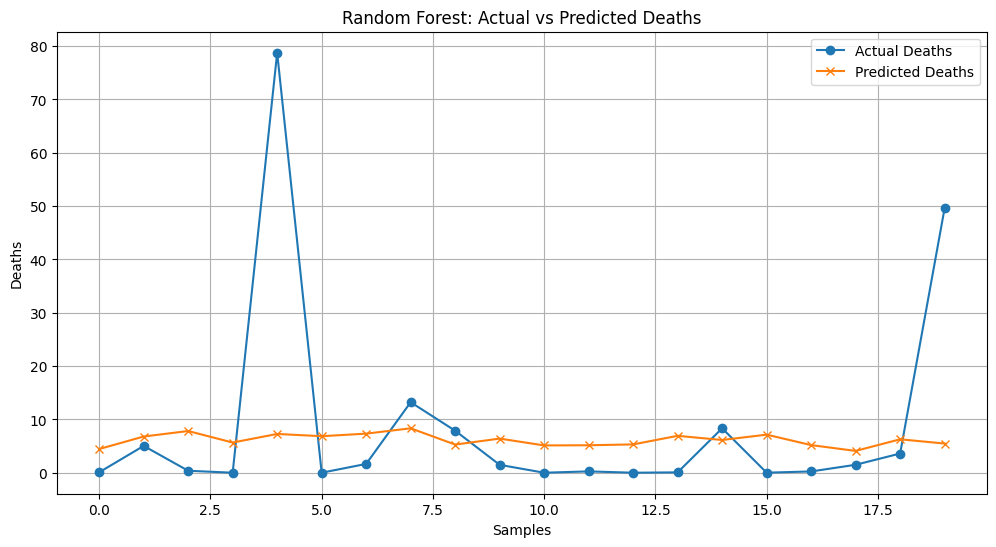

In [95]:
import matplotlib.pyplot as plt

pdf = pred_df.limit(20).toPandas()

plt.figure(figsize=(12,6))

plt.plot(pdf['deaths'].values, label='Actual Deaths', marker='o')
plt.plot(pdf['prediction'].values, label='Predicted Deaths', marker='x')

plt.title('Random Forest: Actual vs Predicted Deaths')
plt.xlabel('Samples')
plt.ylabel('Deaths')

plt.legend()
plt.grid(True)

plt.show()

##   Model Evaluation

In [96]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["RMSE", "R2 Score"],
    "Value": [rmse, r2]
})

results

,Metric,Value
0,RMSE,22.132075
1,R2 Score,0.003676


# **random forest model**

In [55]:
rf = RandomForestRegressor(
    featuresCol='features',
    labelCol='deaths',
    numTrees=100,
    maxBins=200
)

# **Build Random Forest** **Pipeline**

In [56]:
rf_pipeline = Pipeline(stages=[
    country_indexer,
    sex_indexer,
    cause_indexer,
    assembler,
    rf
])

# **Train Random Forest Model**

In [61]:
rf_pipeline = Pipeline(stages=[
    country_indexer,
    sex_indexer,
    cause_indexer,
    assembler,
    rf
])

rf_model = rf_pipeline.fit(train_data)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


# **Predictions**

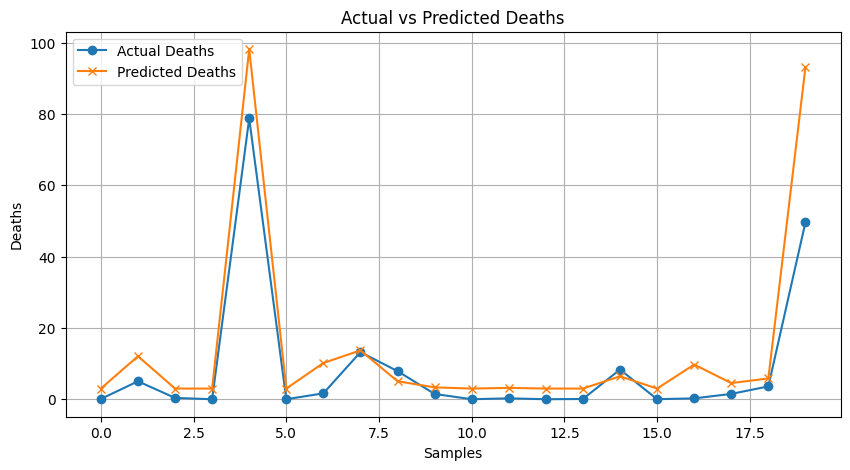

In [93]:
import matplotlib.pyplot as plt

pdf = rf_predictions.select('deaths', 'prediction') \
    .limit(20) \
    .toPandas()

plt.figure(figsize=(10,5))

plt.plot(pdf['deaths'].values, label='Actual Deaths', marker='o')
plt.plot(pdf['prediction'].values, label='Predicted Deaths', marker='x')

plt.title('Actual vs Predicted Deaths')
plt.xlabel('Samples')
plt.ylabel('Deaths')
plt.legend()
plt.grid(True)

plt.show()

# **Evaluate Random Forest**

In [97]:
import pandas as pd

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "RMSE": [rf_rmse],
    "R2 Score": [rf_r2]
})

rf_results

,Model,RMSE,R2 Score
0,Random Forest,15.829958,0.490298


# **GBT Model**

In [107]:
from pyspark.ml.regression import GBTRegressor
from pyspark.ml import Pipeline

GBTRegressor(
    featuresCol="features",
    labelCol="deaths",
    maxIter=100,
    maxDepth=8,
    stepSize=0.1
)


gbt_pipeline = Pipeline(stages=[
    country_indexer,
    sex_indexer,
    cause_indexer,
    assembler,
    gbt
])

gbt_model = gbt_pipeline.fit(train_data)

print("GBT Model Trained Successfully")

GBT Model Trained Successfully


# **prediction**

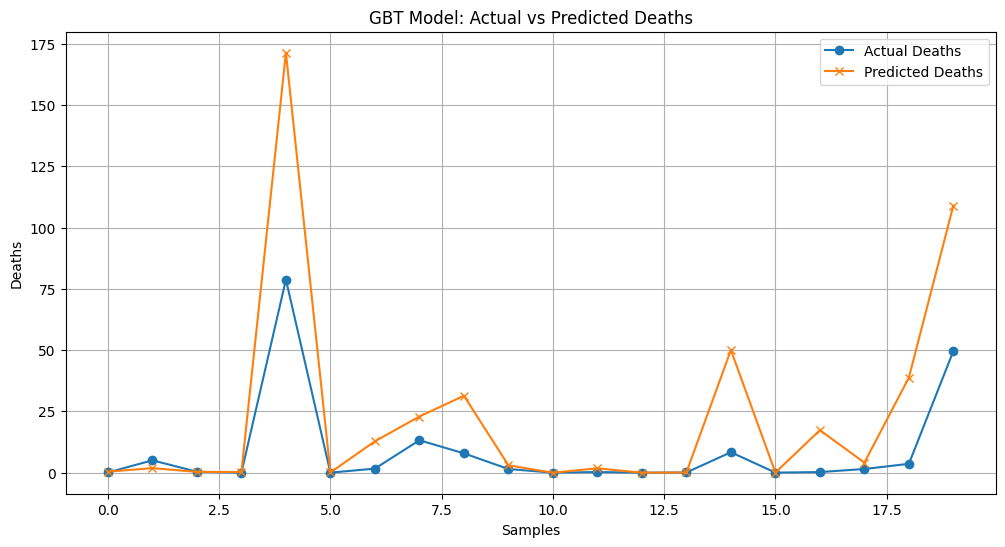

In [108]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, round

# Generate GBT predictions
gbt_predictions = gbt_model.transform(test_data)

# Select and round the deaths and prediction columns for gbt_df
gbt_df = gbt_predictions.select(
    col("deaths"),
    col("prediction")
).withColumn("deaths", round(col("deaths"), 2)) \
 .withColumn("prediction", round(col("prediction"), 2))

# Limit to 20 samples and convert to Pandas for plotting
pdf = gbt_df.limit(20).toPandas()

plt.figure(figsize=(12,6))

plt.plot(pdf["deaths"].values, label="Actual Deaths", marker="o")
plt.plot(pdf["prediction"].values, label="Predicted Deaths", marker="x")

plt.title("GBT Model: Actual vs Predicted Deaths")
plt.xlabel("Samples")
plt.ylabel("Deaths")

plt.legend()
plt.grid(True)

plt.show()

# **evaluation**

In [110]:
import pandas as pd
from pyspark.ml.evaluation import RegressionEvaluator



# Evaluate GBT model
evaluator_rmse_gbt = RegressionEvaluator(
    labelCol='deaths',
    predictionCol='prediction',
    metricName='rmse'
)
gbt_rmse = evaluator_rmse_gbt.evaluate(gbt_predictions)

evaluator_r2_gbt = RegressionEvaluator(
    labelCol='deaths',
    predictionCol='prediction',
    metricName='r2'
)
gbt_r2 = evaluator_r2_gbt.evaluate(gbt_predictions)

print(f"GBT Regressor RMSE: {gbt_rmse}")
print(f"GBT Regressor R2 Score: {gbt_r2}")

gbt_results = pd.DataFrame({
    "Model": ["GBT Regressor"],
    "RMSE": [gbt_rmse],
    "R2 Score": [gbt_r2]
})

gbt_results

GBT Regressor RMSE: 26.39546250568872
GBT Regressor R2 Score: -0.4171471854594877


,Model,RMSE,R2 Score
0,GBT Regressor,26.395463,-0.417147


# **Compare Both Models**

# **RMSE Comparison**

In [113]:
comparison_data = [
    ("Linear Regression", rmse, r2),
    ("Random Forest", rf_rmse, rf_r2),
    ("GBT", gbt_rmse, gbt_r2)
]

comparison_df = spark.createDataFrame(
    comparison_data,
    ["Model", "RMSE", "R2 Score"]
)

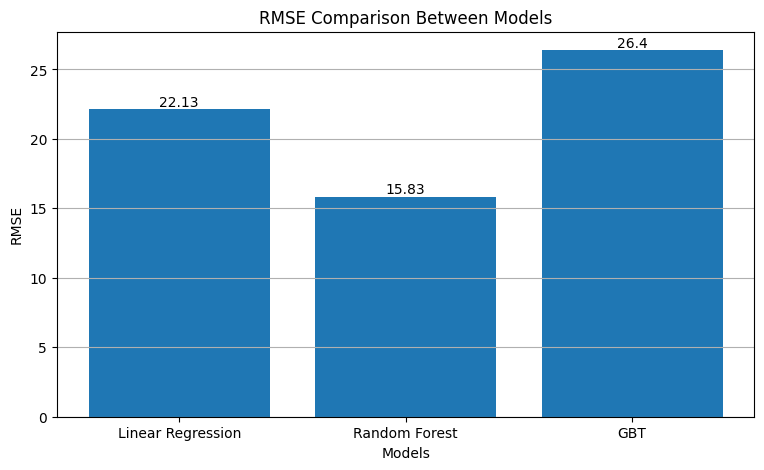

In [115]:
import matplotlib.pyplot as plt

pdf = comparison_df.toPandas()

plt.figure(figsize=(9,5))

bars = plt.bar(pdf['Model'], pdf['RMSE'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             __builtins__.round(yval, 2),
             ha='center', va='bottom')

plt.title('RMSE Comparison Between Models')
plt.ylabel('RMSE')
plt.xlabel('Models')
plt.grid(True, axis='y')

plt.show()

# **R2 Score Comparison**

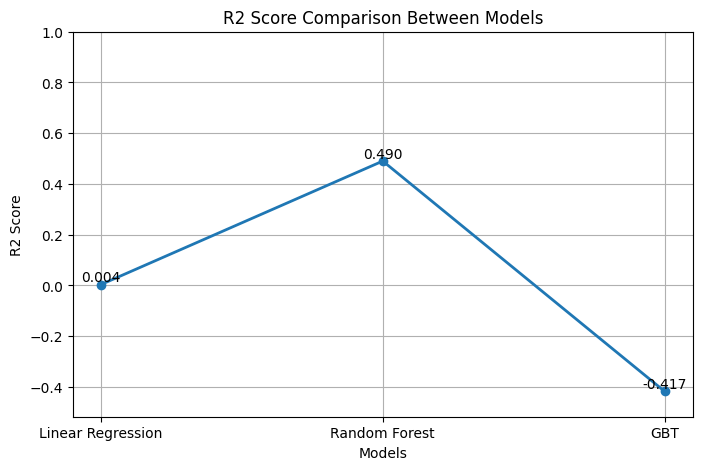

In [126]:
import matplotlib.pyplot as plt

pdf = comparison_df.toPandas()

# تأكد إن القيم رقمية
pdf['R2 Score'] = pdf['R2 Score'].astype(float)

# إزالة أي NaN لو موجود
pdf = pdf.dropna()

x = range(len(pdf))

plt.figure(figsize=(8,5))

plt.plot(x, pdf['R2 Score'], marker='o', linewidth=2)

plt.xticks(x, pdf['Model'])

# إضافة القيم فوق النقاط
for i, v in enumerate(pdf['R2 Score']):
    if v is not None:
        plt.text(i, v, f"{v:.3f}",
                 ha='center', va='bottom')

plt.title('R2 Score Comparison Between Models')
plt.xlabel('Models')
plt.ylabel('R2 Score')

plt.grid(True)

# safe ylim (مهم جدًا لتجنب errors)
min_val = float(min(pdf['R2 Score']))
max_val = float(max(pdf['R2 Score']))

plt.ylim(min(min_val - 0.1, 0), 1)

plt.show()